# Pizza Place Sales Analysis

In [66]:
import pandas as pd
import seaborn as sns
sns.set() #default style of seaborn
import warnings
warnings.filterwarnings("ignore")

In [67]:
orders = pd.read_csv(r"C:\Users\URCHGREAT\Downloads\Assignment 3\pizza_sales\orders.csv")
order_details = pd.read_csv(r"C:\Users\URCHGREAT\Downloads\Assignment 3\pizza_sales\order_details.csv")
pizzas = pd.read_csv(r"C:\Users\URCHGREAT\Downloads\Assignment 3\pizza_sales\pizzas.csv")
pizza_types = pd.read_csv(r"C:\Users\URCHGREAT\Downloads\Assignment 3\pizza_sales\pizza_types.csv", encoding="latin-1")

In [68]:
orders.head()

,order_id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28
3,4,2015-01-01,12:16:31
4,5,2015-01-01,12:21:30


In [69]:
order_details.head()

,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1


In [70]:
pizzas.head()

,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75


In [71]:
pizza_types.head()

,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja..."


In [72]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21350 entries, 0 to 21349
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   order_id  21350 non-null  int64 
 1   date      21350 non-null  object
 2   time      21350 non-null  object
dtypes: int64(1), object(2)
memory usage: 500.5+ KB


In [73]:
# Convert the 'date' column from plain text to a proper datetime type
# This lets pandas understand it as an actual date, so we can later
# extract things like day-of-week, month, etc. directly from it
orders['date'] = pd.to_datetime(orders['date'])

In [74]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21350 entries, 0 to 21349
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   order_id  21350 non-null  int64         
 1   date      21350 non-null  datetime64[ns]
 2   time      21350 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 500.5+ KB


In [75]:
# Convert the 'time' column from plain text to a proper datetime type
# We only care about the time portion, but pandas needs a full datetime
# to parse it correctly, so it will attach today's date temporarily
orders['time'] = pd.to_datetime(orders['time'])

# Extract just the hour (0-23) from the time and store it in a new column
# This will let us group orders by hour later to find peak sales hours
orders['hour'] = orders['time'].dt.hour

In [76]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21350 entries, 0 to 21349
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   order_id  21350 non-null  int64         
 1   date      21350 non-null  datetime64[ns]
 2   time      21350 non-null  datetime64[ns]
 3   hour      21350 non-null  int32         
dtypes: datetime64[ns](2), int32(1), int64(1)
memory usage: 583.9 KB


In [77]:
orders.head()

,order_id,date,time,hour
0,1,2015-01-01,2026-07-05 11:38:36,11
1,2,2015-01-01,2026-07-05 11:57:40,11
2,3,2015-01-01,2026-07-05 12:12:28,12
3,4,2015-01-01,2026-07-05 12:16:31,12
4,5,2015-01-01,2026-07-05 12:21:30,12


In [78]:
# Merge orders with order_details using 'order_id' as the common key
# This attaches date, time, and hour info to each pizza ordered
df = pd.merge(order_details, orders, on='order_id')

# Merge the result with pizzas using 'pizza_id' as the common key
# This attaches pizza size and price to each order line
df = pd.merge(df, pizzas, on='pizza_id')

# Merge the result with pizza_types using 'pizza_type_id' as the common key
# This attaches pizza name, category, and ingredients to each order line
df = pd.merge(df, pizza_types, on='pizza_type_id')

In [79]:
df.head()

,order_details_id,order_id,pizza_id,quantity,date,time,hour,pizza_type_id,size,price,name,category,ingredients
0,1,1,hawaiian_m,1,2015-01-01,2026-07-05 11:38:36,11,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
1,2,2,classic_dlx_m,1,2015-01-01,2026-07-05 11:57:40,11,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
2,3,2,five_cheese_l,1,2015-01-01,2026-07-05 11:57:40,11,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go..."
3,4,2,ital_supr_l,1,2015-01-01,2026-07-05 11:57:40,11,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
4,5,2,mexicana_m,1,2015-01-01,2026-07-05 11:57:40,11,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_details_id  48620 non-null  int64         
 1   order_id          48620 non-null  int64         
 2   pizza_id          48620 non-null  object        
 3   quantity          48620 non-null  int64         
 4   date              48620 non-null  datetime64[ns]
 5   time              48620 non-null  datetime64[ns]
 6   hour              48620 non-null  int32         
 7   pizza_type_id     48620 non-null  object        
 8   size              48620 non-null  object        
 9   price             48620 non-null  float64       
 10  name              48620 non-null  object        
 11  category          48620 non-null  object        
 12  ingredients       48620 non-null  object        
dtypes: datetime64[ns](2), float64(1), int32(1), int64(3), object(6)
memory usage

In [81]:
# Calculate total revenue for each order line by multiplying price by quantity
# This accounts for cases where more than one of the same pizza was ordered
df['revenue'] = df['price'] * df['quantity']

In [82]:
df.head()

,order_details_id,order_id,pizza_id,quantity,date,time,hour,pizza_type_id,size,price,name,category,ingredients,revenue
0,1,1,hawaiian_m,1,2015-01-01,2026-07-05 11:38:36,11,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25
1,2,2,classic_dlx_m,1,2015-01-01,2026-07-05 11:57:40,11,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00
2,3,2,five_cheese_l,1,2015-01-01,2026-07-05 11:57:40,11,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50
3,4,2,ital_supr_l,1,2015-01-01,2026-07-05 11:57:40,11,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75
4,5,2,mexicana_m,1,2015-01-01,2026-07-05 11:57:40,11,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00


### 1. What is the total revenue/sales?

In [83]:
# Sum the revenue column across all rows to get total sales revenue
total_revenue = df['revenue'].sum()

# Print the result, rounded to 2 decimal places, since we're dealing with money
print(f"Total Revenue: ${total_revenue:.2f}")

Total Revenue: $817860.05


The pizza place generated a total revenue of $817,860.05 over the course of the year.

### 2. Total Quantity Sold

In [84]:
# Sum the quantity column to find the total number of pizzas sold
total_quantity = df['quantity'].sum()

# Print the result
print(f"Total Quantity Sold: {total_quantity}")

Total Quantity Sold: 49574


A total of 49,574 pizzas were sold over the year.

### 3. Total Orders

In [85]:
# Count the number of unique order_id values to get the total number of orders
# We use nunique() instead of count() because one order can contain multiple
# pizzas (multiple rows), so we don't want to count those rows separately
total_orders = df['order_id'].nunique()

# Print the result
print(f"Total Orders: {total_orders}")

Total Orders: 21350


The pizza place processed a total of 21,350 orders over the year.

### 4. How many pizza types do they sell?

In [86]:
# Count the number of unique pizza type names to find how many distinct
# pizza types are on the menu (not counting different sizes as separate types)
num_pizza_types = df['name'].nunique()

# Print the result
print(f"Number of Pizza Types: {num_pizza_types}")

Number of Pizza Types: 32


The pizza place offers 32 distinct types of pizza.

### 5. Average Pizza Price

In [87]:
# Calculate the average price using the original 'pizzas' dataframe,
# not the merged df — this gives the average price per pizza/size
# combination, rather than being skewed by how often each was ordered
average_price = pizzas['price'].mean()

# Print the result, rounded to 2 decimal places
print(f"Average Pizza Price: ${average_price:.2f}")

Average Pizza Price: $16.44


The average price of a pizza on the menu is $16.44.

### 6.	What are the peak hours of sales?

In [88]:
# Group all order lines by the hour they were placed, and count how many
# orders happened in each hour using order_id (counting unique orders,
# not just rows, to avoid double-counting orders with multiple pizzas)
orders_by_hour = df.groupby('hour')['order_id'].nunique()

# Sort the results in descending order so the busiest hours appear first
orders_by_hour = orders_by_hour.sort_values(ascending=False)

# Print the result
print(orders_by_hour)

hour
12    2520
13    2455
18    2399
17    2336
19    2009
16    1920
20    1642
14    1472
15    1468
11    1231
21    1198
22     663
23      28
10       8
9        1
Name: order_id, dtype: int64


Sales peak at 12 PM (noon) with 2,520 orders, followed closely by 1 PM 
with 2,455 orders. There's also a strong dinner rush between 5-7 PM. 
Very few orders are placed before 10 AM or after 10 PM, matching typical 
lunch and dinner dining patterns.

#### Peak Hours Chart

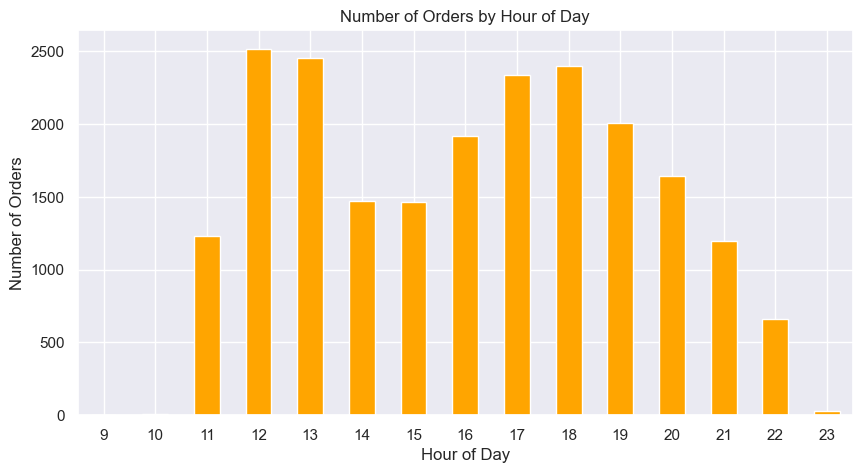

In [89]:
# Import matplotlib for plotting graphs
import matplotlib.pyplot as plt

# Create a bar chart showing number of orders per hour
# We use .sort_index() here (not sort_values) so the hours appear
# in natural order (0-23) along the x-axis instead of busiest-first
orders_by_hour.sort_index().plot(kind='bar', figsize=(10, 5), color='orange')

# Add a title and axis labels so the chart is easy to read
plt.title('Number of Orders by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')

# Rotate the x-axis labels so they don't overlap
plt.xticks(rotation=0)

# Display the chart
plt.show()

### 7.	Find the total sales made on each day of the week. Which day of the week is when sales are made the most?

In [90]:
# Extract the day name (e.g. 'Monday') from the date column
# day_name() reads the weekday directly from the datetime value
df['day_of_week'] = df['date'].dt.day_name()

# Group by day of week and sum the revenue for each day
sales_by_day = df.groupby('day_of_week')['revenue'].sum()

# Define the correct order of days (Monday to Sunday) since groupby
# sorts alphabetically by default, which isn't useful here
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Reindex the result using our custom day order
sales_by_day = sales_by_day.reindex(day_order)

# Print the result
print(sales_by_day)

day_of_week
Monday       107329.55
Tuesday      114133.80
Wednesday    114408.40
Thursday     123528.50
Friday       136073.90
Saturday     123182.40
Sunday        99203.50
Name: revenue, dtype: float64


Friday generates the highest sales at $136,073.90, while Sunday has the 
lowest at $99,203.50. Sales build up steadily from Monday through Friday, 
then decline over the weekend — suggesting the pizza place may draw more 
weekday/lunch crowd business than weekend traffic.

#### Sales by Day of Week Chart

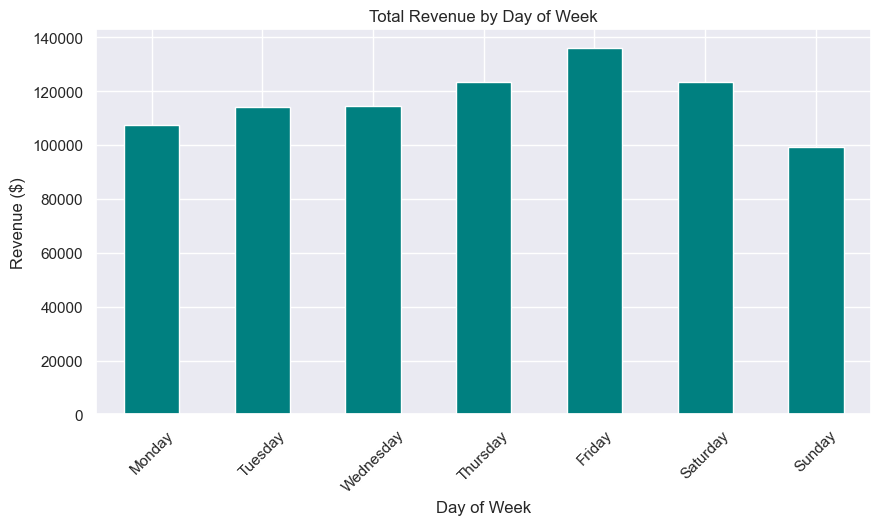

In [91]:
# Create a bar chart showing total revenue by day of the week
sales_by_day.plot(kind='bar', figsize=(10, 5), color='teal')

# Add title and axis labels
plt.title('Total Revenue by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Revenue ($)')

# Rotate x-axis labels so the day names are horizontal and readable
plt.xticks(rotation=45)

# Display the chart
plt.show()

### 8. Top 5 Bestselling Pizzas

In [92]:
# Group by pizza name and sum the quantity sold for each one
# This tells us which pizzas sold the most units overall
top_pizzas = df.groupby('name')['quantity'].sum()

# Sort in descending order and keep only the top 5
top_pizzas = top_pizzas.sort_values(ascending=False).head(5)

# Print the result
print(top_pizzas)

name
The Classic Deluxe Pizza      2453
The Barbecue Chicken Pizza    2432
The Hawaiian Pizza            2422
The Pepperoni Pizza           2418
The Thai Chicken Pizza        2371
Name: quantity, dtype: int64


The top 5 bestselling pizzas by quantity sold are:
1. The Classic Deluxe Pizza - 2,453 units
2. The Barbecue Chicken Pizza - 2,432 units
3. The Hawaiian Pizza - 2,422 units
4. The Pepperoni Pizza - 2,418 units
5. The Thai Chicken Pizza - 2,371 units

These top sellers are fairly close in numbers, showing a diverse group of 
crowd favorites rather than one dominant pizza — spanning both classic 
and more adventurous flavor profiles.

#### Top 5 Bestselling Pizzas Chart

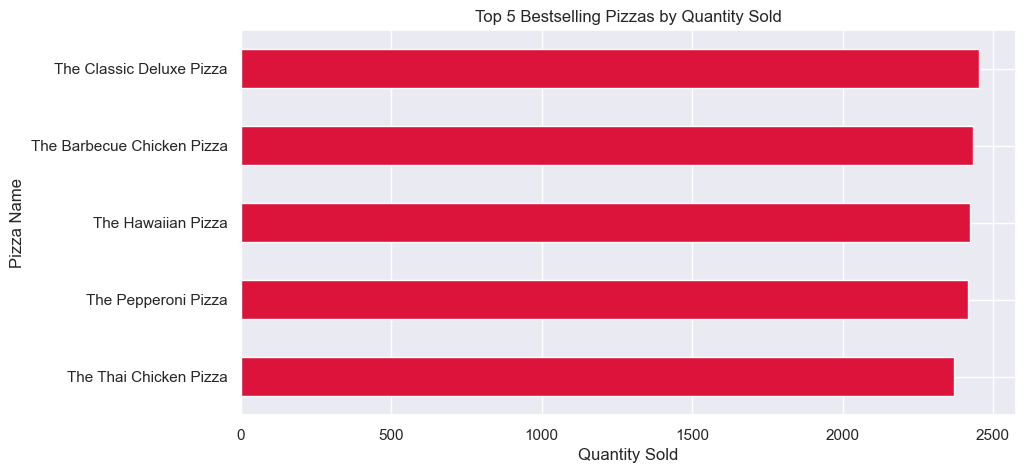

In [93]:
# Create a horizontal bar chart for the top 5 bestselling pizzas
# sort_values(ascending=True) here makes the chart display with the
# highest-selling pizza at the top when plotted horizontally
top_pizzas.sort_values(ascending=True).plot(kind='barh', figsize=(10, 5), color='crimson')

# Add title and axis labels
plt.title('Top 5 Bestselling Pizzas by Quantity Sold')
plt.xlabel('Quantity Sold')
plt.ylabel('Pizza Name')

# Display the chart
plt.show()

### 9.	Find the sales made in each month. Any trend noticeable?

In [94]:
# Extract the month name (e.g. 'January') from the date column
df['month'] = df['date'].dt.month_name()

# Group by month and sum the revenue for each one
sales_by_month = df.groupby('month')['revenue'].sum()

# Define the correct calendar order for months, since groupby
# sorts alphabetically by default
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Reindex using the correct month order
sales_by_month = sales_by_month.reindex(month_order)

# Print the result
print(sales_by_month)

month
January      69793.30
February     65159.60
March        70397.10
April        68736.80
May          71402.75
June         68230.20
July         72557.90
August       68278.25
September    64180.05
October      64027.60
November     70395.35
December     64701.15
Name: revenue, dtype: float64


Monthly sales are fairly consistent throughout the year, ranging from 
about $64,000 to $72,500. July is the strongest month ($72,557.90), while 
September and October are the weakest (~$64,000 each). There's a slight 
uptick in the summer months (May-July), but no dramatic seasonal trend — 
revenue stays relatively steady year-round.

#### Sales by Month Chart

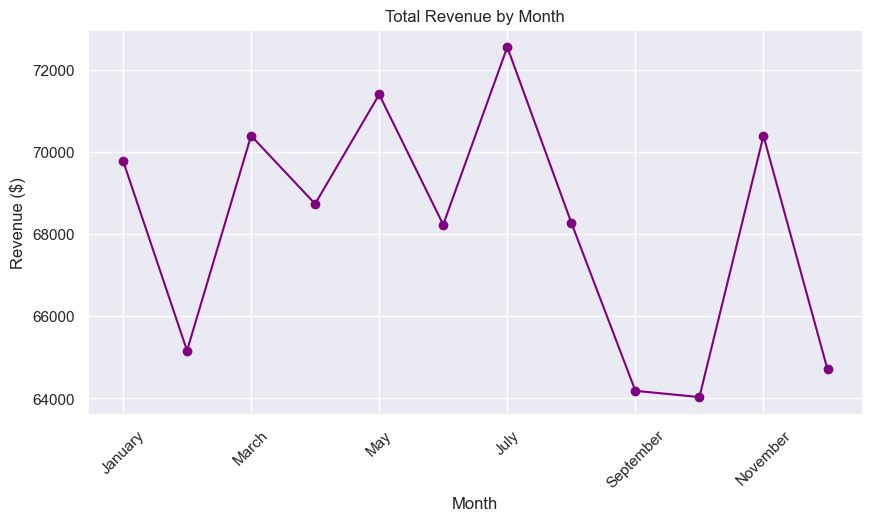

In [95]:
# Create a line chart to visualize the revenue trend across months
sales_by_month.plot(kind='line', marker='o', figsize=(10, 5), color='purple')

# Add title and axis labels
plt.title('Total Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')

# Rotate x-axis labels so month names don't overlap
plt.xticks(rotation=45)

# Add gridlines to make the trend easier to read
plt.grid(True)

# Display the chart
plt.show()

### 10.	Are there pizza types that are not doing well on the menu?

In [96]:
# Reuse the same grouping as before (by pizza name), but this time
# sort in ascending order to find the worst performers instead of best
bottom_pizzas = df.groupby('name')['quantity'].sum()
bottom_pizzas = bottom_pizzas.sort_values(ascending=True).head(5)

# Print the result
print(bottom_pizzas)

name
The Brie Carre Pizza         490
The Mediterranean Pizza      934
The Calabrese Pizza          937
The Spinach Supreme Pizza    950
The Soppressata Pizza        961
Name: quantity, dtype: int64


The Brie Carre Pizza is a clear underperformer, selling only 490 units — 
nearly half of the next lowest pizza (Mediterranean, 934 units). The 
other bottom performers (Mediterranean, Calabrese, Spinach Supreme, 
Soppressata) are clustered closely together around 934-961 units, 
suggesting Brie Carre specifically may need a menu review — possibly due 
to pricing, niche ingredients (brie isn't a common pizza topping), or 
low visibility on the menu.

### Extra Insight 1: Revenue by Category

#### Revenue by Pizza Category

In [97]:
# Group by pizza category (Classic, Veggie, Supreme, Chicken) and sum revenue
revenue_by_category = df.groupby('category')['revenue'].sum()

# Sort in descending order so the best-performing category appears first
revenue_by_category = revenue_by_category.sort_values(ascending=False)

# Print the result
print(revenue_by_category)

category
Classic    220053.10
Supreme    208197.00
Chicken    195919.50
Veggie     193690.45
Name: revenue, dtype: float64


Classic pizzas generate the most revenue ($220,053.10), followed closely 
by Supreme ($208,197.00), Chicken ($195,919.50), and Veggie ($193,690.45). 
The gap between the top and bottom category is relatively small (about 
12%), showing customers have fairly balanced preferences across all 
pizza categories rather than favoring one type heavily.

##### Revenue by Category Chart

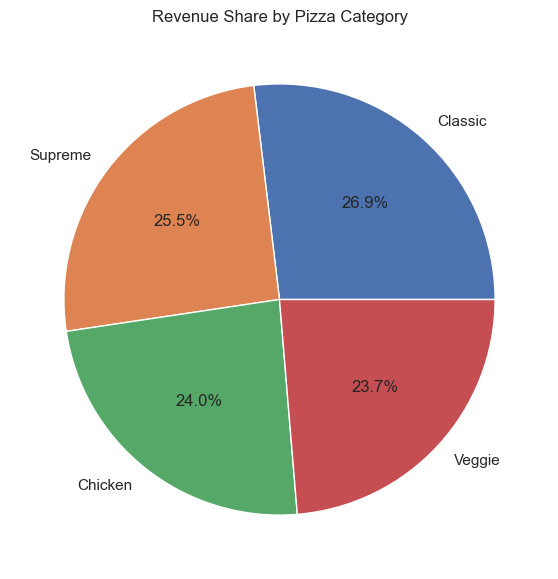

In [98]:
# Create a pie chart to show each category's share of total revenue
# autopct displays the percentage on each slice, rounded to 1 decimal place
revenue_by_category.plot(kind='pie', autopct='%1.1f%%', figsize=(7, 7))

# Add a title
plt.title('Revenue Share by Pizza Category')

# Remove the default y-axis label (pandas adds one automatically for pie charts)
plt.ylabel('')

# Display the chart
plt.show()

### Extra Insight 2: Revenue by pizza size 

#### Revenue by Pizza Size

In [99]:
# Group by pizza size (S, M, L, XL, XXL) and sum revenue
revenue_by_size = df.groupby('size')['revenue'].sum()

# Sort in descending order so the best-selling size appears first
revenue_by_size = revenue_by_size.sort_values(ascending=False)

# Print the result
print(revenue_by_size)

size
L      375318.70
M      249382.25
S      178076.50
XL      14076.00
XXL      1006.60
Name: revenue, dtype: float64


Large pizzas dominate revenue at $375,318.70 — more than Medium and Small 
combined would need to catch up. Medium follows at $249,382.25, then 
Small at $178,076.50. XL ($14,076.00) and XXL ($1,006.60) are negligible, 
together contributing less than 2% of total revenue. This suggests the 
menu could potentially phase out or reconsider XL/XXL sizes, or that 
they need better promotion if they're meant to be a meaningful offering.

##### Revenue by Size Chart

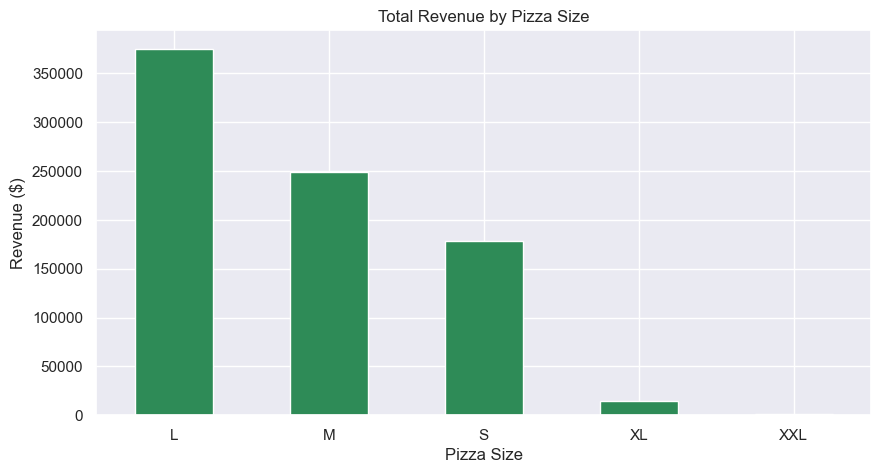

In [100]:
# Create a bar chart showing revenue by pizza size
revenue_by_size.plot(kind='bar', figsize=(10, 5), color='seagreen')

# Add title and axis labels
plt.title('Total Revenue by Pizza Size')
plt.xlabel('Pizza Size')
plt.ylabel('Revenue ($)')

# Keep x-axis labels horizontal since size labels are short
plt.xticks(rotation=0)

# Display the chart
plt.show()